<div style="background: linear-gradient(90deg, #1a2a6c 0%, #203a43 50%, #2c5364 100%); 
            padding: 30px; 
            border-radius: 15px; 
            color: #ffffff; 
            font-family: 'Segoe UI', sans-serif; 
            text-align: center; 
            box-shadow: 0 10px 20px rgba(0,0,0,0.3); 
            border: 2px solid #3498db;">
    <h1 style="margin: 0; font-size: 36px; letter-spacing: 2px;">💤 Predict quality of Sleep 💤</h1>
    <p style="margin: 10px 0 0 0; opacity: 0.8; font-style: italic; text-align: center;">Analyzing Data, Building Models & Explain predictions</p>
</div>


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">       🔗 Import Libraries</div>


In [1]:
import numpy as np
import pandas as pd

# Libraries for advanced data structures
from collections import defaultdict, Counter

# Progress bar for loops
from tqdm import tqdm

# Joblib for saving models or large data files efficiently
import joblib

# Libraries for Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib import cm
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency, norm, fisher_exact

# Scikit-learn Model Selection
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold

# LightGBM libraries for building models
import xgboost as xgb
import lightgbm as lgb
from lightgbm.sklearn import LGBMClassifier, LGBMRegressor

# Scikit-learn Metrics for Model Evaluation
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import wasserstein_distance
from scipy.signal import get_window, detrend

# Others
from math import sqrt
import re
import gc # Garbage collector
import os
import time
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import kurtosis, rankdata, combine_pvalues, spearmanr, kendalltau
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression

# Shap-values (model explicability)
import shap

# Ignore warnings
import warnings
#warnings.filterwarnings("ignore", category=UserWarning)
#warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = '#f0f2f6'
pd.set_option('display.max_columns', 50)


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">       🔗 Utils</div>


In [2]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, 
                                  figsize=(8, 6), cmap='Blues', 
                                  title='Confusion Matrix', 
                                  normalize=False, 
                                  show_values=True,
                                  value_format='.0f',
                                  title_size=16,
                                  label_size=12):
    """
    Plot a confusion matrix to evaluate the performance of a classification model.

    The confusion matrix compares true labels with predicted labels and highlights
    correct predictions and classification errors. Optionally, values can be
    normalized to show proportions instead of raw counts.

    Parameters
    ----------
    y_true : array-like
        True class labels.
    y_pred : array-like
        Predicted class labels.
    class_names : list of str, optional
        Display names for the classes.
    figsize : tuple, optional
        Size of the figure.
    cmap : str, optional
        Colormap used for the heatmap.
    title : str, optional
        Title of the plot.
    normalize : bool, optional
        If True, normalize values by true class (row-wise).
    show_values : bool, optional
        Whether to display values inside the matrix cells.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Matplotlib figure object.
    ax : matplotlib.axes.Axes
        Matplotlib axes object.
    """

    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        value_format = '.2%' if value_format == '.0f' else value_format
    
    # Set up class names
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(cm))]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(cm, 
                annot=show_values,
                fmt=value_format,
                cmap=cmap,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                ax=ax,
                annot_kws={'size': label_size})
    
    # Customize the plot
    ax.set_title(title, fontsize=title_size, fontweight='bold', pad=20)
    ax.set_xlabel('Predicted Label', fontsize=label_size, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=label_size, fontweight='bold')
    
    # Set tick labels
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names, rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">       🔗 Load Data</div>


The 32 columns are organized into 7 logical groups:

| Group            | Columns                                                                                                                                 | Purpose               |
|------------------|-----------------------------------------------------------------------------------------------------------------------------------------|-----------------------|
| Demographics     | person_id, age, gender, occupation, bmi, country                                                                                         | Who the person is     |
| Sleep Architecture | sleep_duration_hrs, sleep_quality_score, rem_percentage, deep_sleep_percentage, sleep_latency_mins, wake_episodes_per_night           | How they slept        |
| Lifestyle        | caffeine_mg_before_bed, alcohol_units_before_bed, screen_time_before_bed_mins, exercise_day, steps_that_day, nap_duration_mins         | What they did         |
| Psychological    | stress_score, work_hours_that_day, chronotype, mental_health_condition                                                                  | How they felt         |
| Health Context   | heart_rate_resting_bpm, sleep_aid_used, shift_work, room_temperature_celsius, weekend_sleep_diff_hrs                                    | Health modifiers      |
| Environmental    | season, day_type                                                                                                                         | When the record is from |
| Targets (3)      | cognitive_performance_score, sleep_disorder_risk, felt_rested                                                                           | What to predict       |

In [3]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv')

# Show
print(df.shape)
df.head()

(100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0



# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">       🔗 Modify data for clarity</div>


In [4]:
dict_disorder = {'Healthy' : '1. Healthy',
                 'Mild' : '2. Moderate',
                 'Moderate' : '3. High',
                 'Severe' : '4. Severe',
                }

dict_y = {'Healthy' : '1',
          'Mild' : '2',
          'Moderate' : '3',
          'Severe' : '4',
         }

# Create columns
df['y'] = df['sleep_disorder_risk'].map(dict_y).astype(int)
df['sleep_disorder_risk'] = df['sleep_disorder_risk'].map(dict_disorder)

# Value counts
df['sleep_disorder_risk'].value_counts().to_frame()

,count
sleep_disorder_risk,
1. Healthy,54156
2. Moderate,33479
3. High,8299
4. Severe,4066


___
___

# **Exploratory Data Analysis (EDA)**



# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        💤 Sleep Quality Distribution by Gender </div>


,count
gender,
Female,50203
Male,47823
Other,1974


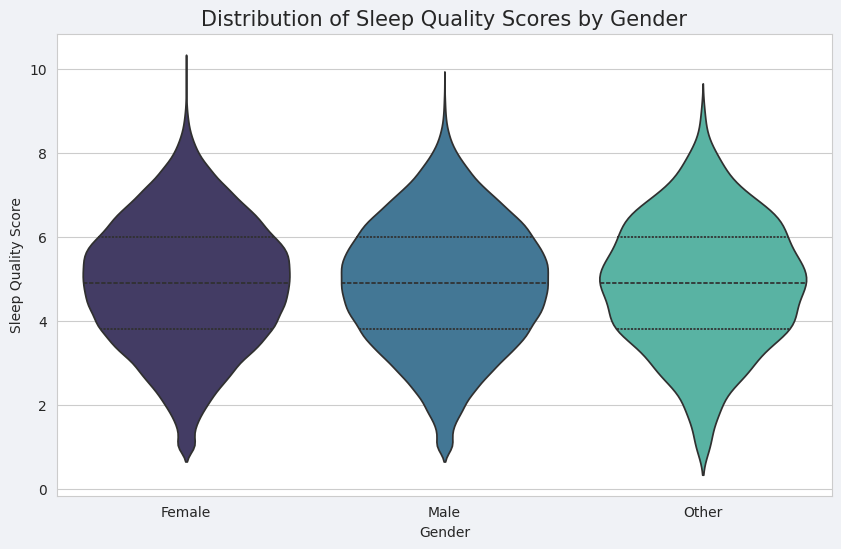

In [5]:
display(df['gender'].value_counts().to_frame())

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='gender', y='sleep_quality_score', hue='gender', palette='mako', inner="quart", legend=False)
plt.title('Distribution of Sleep Quality Scores by Gender', fontsize=15)
plt.xlabel('Gender')
plt.ylabel('Sleep Quality Score')
plt.show()


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        💤 Correlation Matrix of Health Metrics </div>


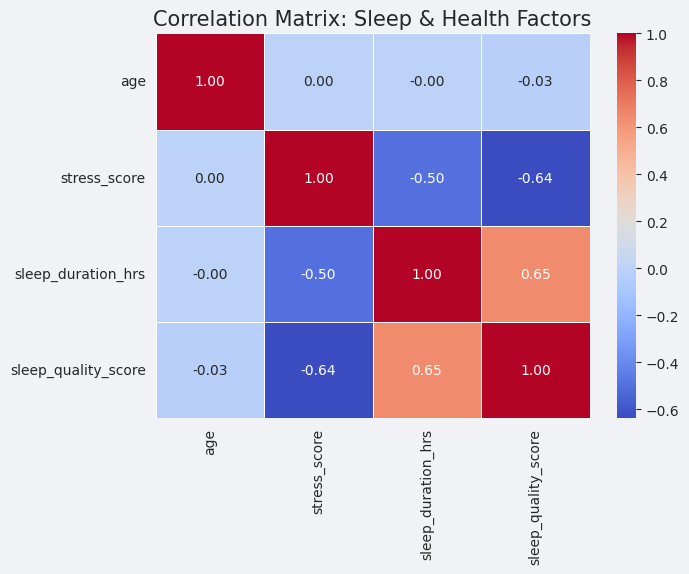

In [6]:
plt.figure(figsize=(7, 5))
corr = df[['age', 'stress_score', 'sleep_duration_hrs', 'sleep_quality_score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Sleep & Health Factors', fontsize=15)
plt.show()

<div style="background-color: #ffffff; 
            border: 1px solid #d1d9e6; 
            border-top: 5px solid #3498db; 
            padding: 20px; 
            border-radius: 10px; 
            color: #2c3e50; 
            font-family: 'Arial', sans-serif; 
            font-size: 1.2rem;
            box-shadow: 2px 2px 10px rgba(0,0,0,0.05);">
    There is a strong correlation between <strong>stress_score</strong> and <strong>sleep_quality_score</strong>. Conversely, <strong>sleep_duration_hrs</strong> and <strong>sleep_quality_score</strong> tend to have a strong positive correlation, suggesting that longer sleep often translates to perceived better quality.
</div>


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        💤 Sleep Duration vs. Cognitive Performance </div>


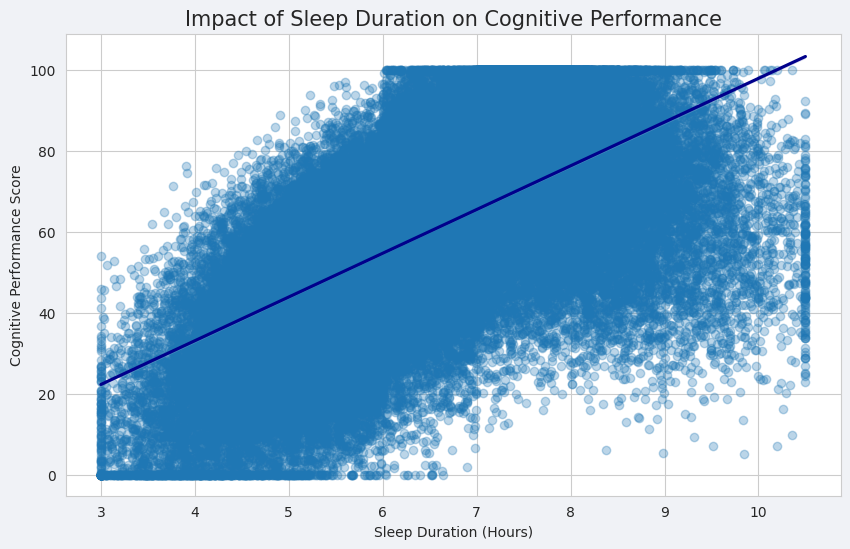

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='sleep_duration_hrs', y='cognitive_performance_score', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'darkblue'})
plt.title('Impact of Sleep Duration on Cognitive Performance', fontsize=15)
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Cognitive Performance Score')
plt.show()

<div style="background-color: #ffffff; 
            border: 1px solid #d1d9e6; 
            border-top: 5px solid #3498db; 
            padding: 20px; 
            border-radius: 10px; 
            color: #2c3e50; 
            font-family: 'Arial', sans-serif; 
            font-size: 1.2rem;
            box-shadow: 2px 2px 10px rgba(0,0,0,0.05);">
    The regression line indicates a positive trend where increased sleep duration leads to higher cognitive performance scores. Low sleep duration (below 5 hours) is frequently associated with significantly lower cognitive output.
</div>


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        💤 Caffeine Consumption vs. Sleep Latency </div>


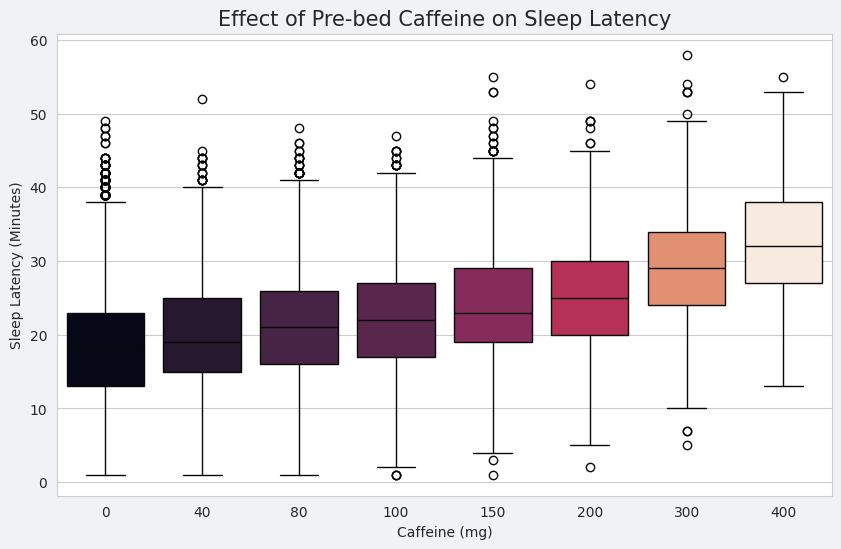

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='caffeine_mg_before_bed', y='sleep_latency_mins', hue='caffeine_mg_before_bed', palette='rocket', legend=False)
plt.title('Effect of Pre-bed Caffeine on Sleep Latency', fontsize=15)
plt.xlabel('Caffeine (mg)')
plt.ylabel('Sleep Latency (Minutes)')
plt.show()

<div style="background-color: #ffffff; 
            border: 1px solid #d1d9e6; 
            border-top: 5px solid #3498db; 
            padding: 20px; 
            border-radius: 10px; 
            color: #2c3e50; 
            font-family: 'Arial', sans-serif; 
            font-size: 1.2rem;
            box-shadow: 2px 2px 10px rgba(0,0,0,0.05);">
    Higher intake of caffeine before bed (e.g., 300mg+) is associated with increased sleep latency, meaning individuals take longer to fall asleep. Those with zero caffeine consumption generally show shorter, healthier latency periods.
</div>

___
___
# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        🛠️ Model Training </div>


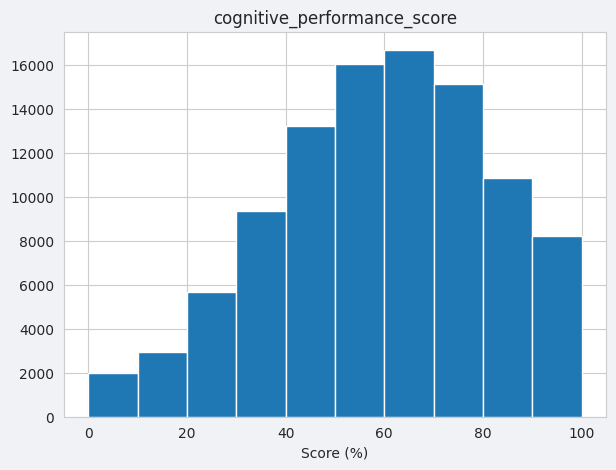

In [9]:
# Target n°1
col = 'cognitive_performance_score'

plt.figure(figsize = (7, 5))
plt.title(col)
plt.xlabel("Score (%)")
df[col].hist(bins=10)
plt.show()

In [10]:
# Target n°2
df['sleep_disorder_risk'].value_counts().to_frame()

,count
sleep_disorder_risk,
1. Healthy,54156
2. Moderate,33479
3. High,8299
4. Severe,4066


In [11]:
# Target n°3
df['felt_rested'].value_counts().to_frame()

,count
felt_rested,
0,60988
1,39012



# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        🛠️ Feature Analysis & Feature Engineering </div>


In [12]:
palette = {
    '1. Healthy': '#2ecc71',   # green
    '2. Moderate': '#1f77b4',  # blue
    '3. High': '#e67e22',      # orange
    '4. Severe': '#e74c3c'     # red
}
order = sorted(df['sleep_disorder_risk'].unique())

### **<u>Feature :</u>** 'occupation'
- Occupational stress significantly impacts sleep health. Professionals like Doctors and Nurses often report higher "Severe" or "Moderate" risk levels for sleep disorders compared to "Retired" individuals, who frequently show "Healthy" sleep profiles. Surprisingly enough, Students report higher "Severe" or "Moderate" risk levels for sleep disorders.

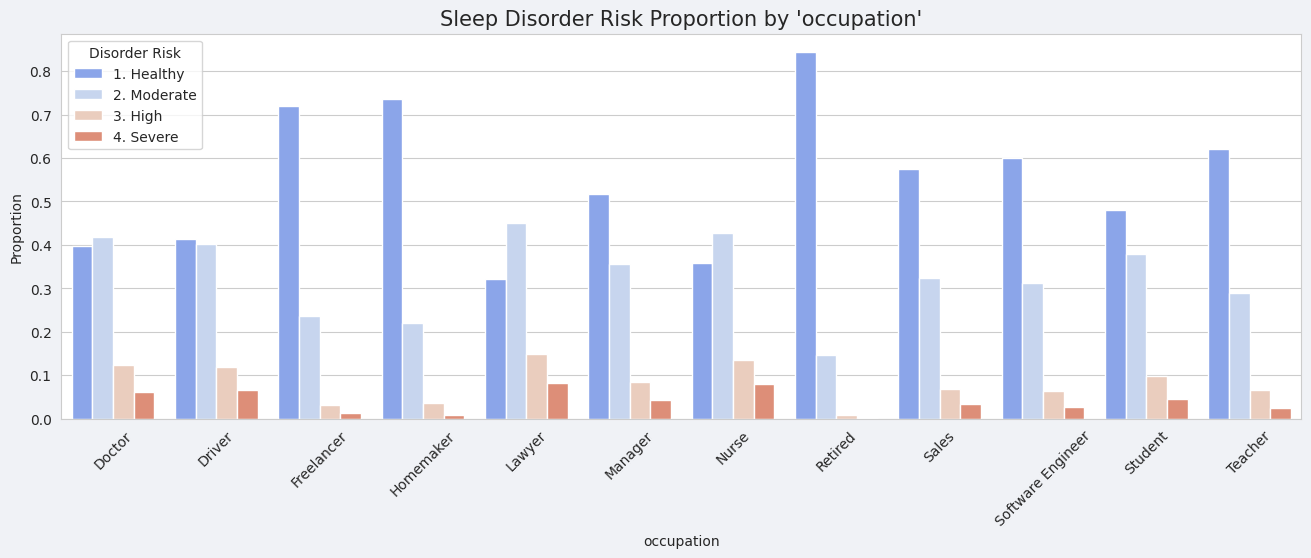

In [13]:
col = 'occupation'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(16, 5))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'felt_rested'
- Not feeling rested is a symptom of severe sleep disorder

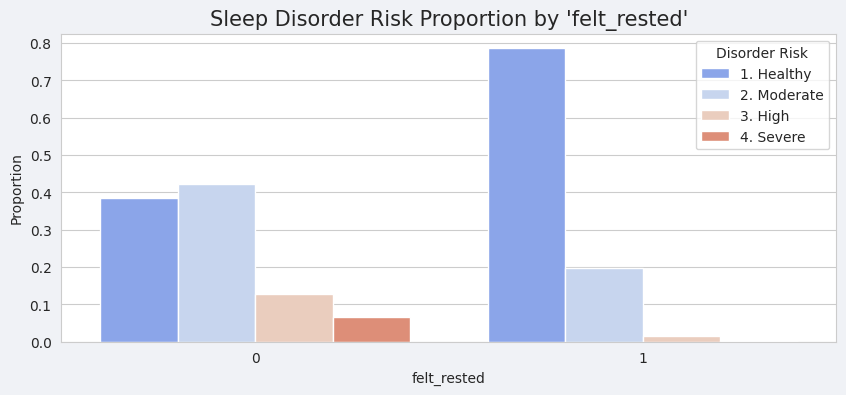

In [14]:
col = 'felt_rested'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'cognitive_performance_score'
- Weekdays increase the risk of severe sleep disorder

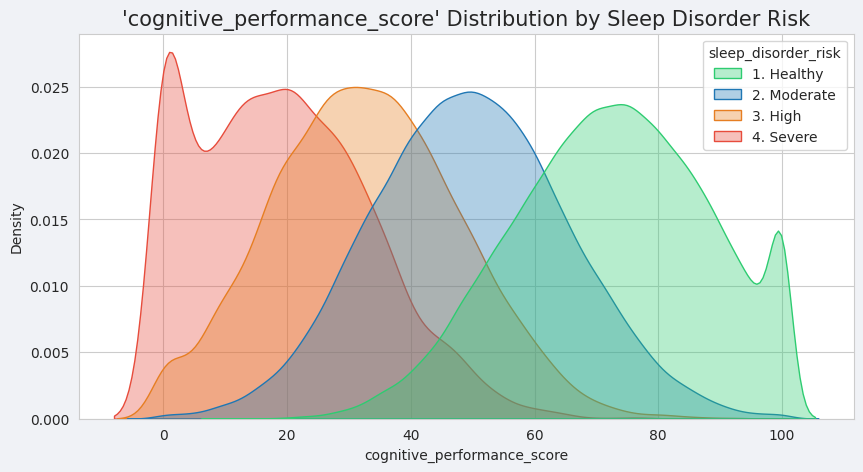

In [15]:
col = 'cognitive_performance_score'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** 'day type'
- Weekdays increase the risk of severe sleep disorder

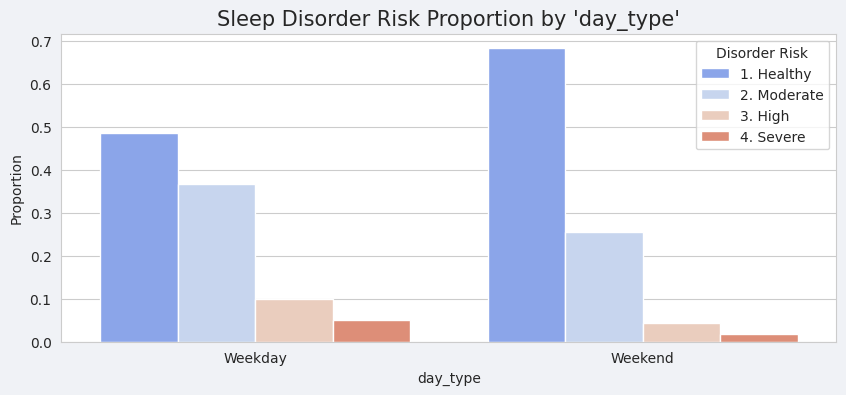

In [16]:
col = 'day_type'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'shift works'
- Shift work increases the risk of severe sleep disorder

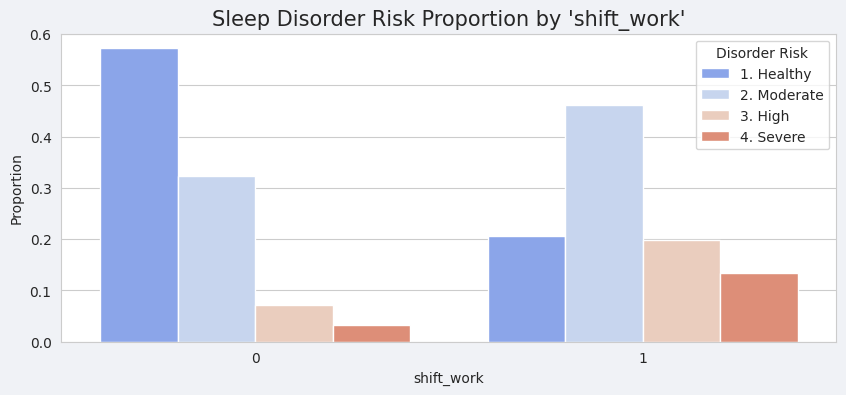

In [17]:
col = 'shift_work'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'sleep aid'
- Sleep aid reduces the risk of severe sleep disorder

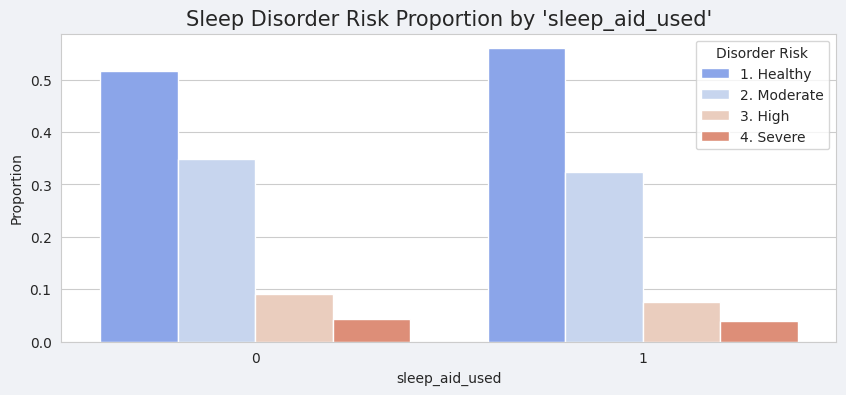

In [18]:
col = 'sleep_aid_used'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'mental_health_condition'
- Mental disorders increase the risk of severe sleep disorder

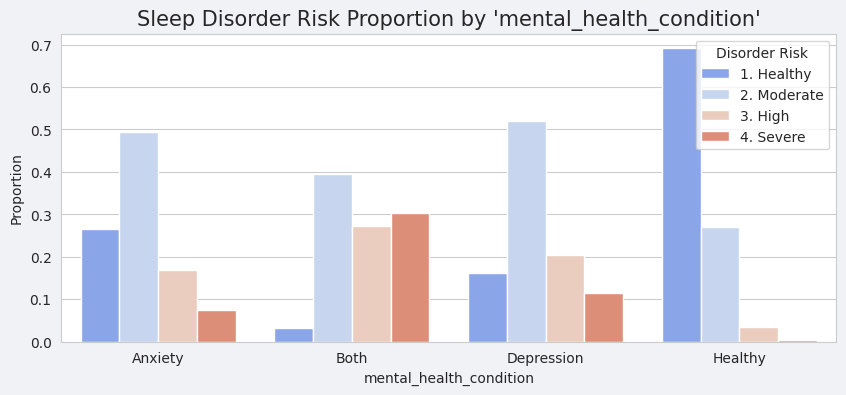

In [19]:
col = 'mental_health_condition'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

In [20]:
df['Anxiety'] = df['mental_health_condition'].isin(['Anxiety', 'Both']).astype(int)
df['Depression'] = df['mental_health_condition'].isin(['Depression', 'Both']).astype(int)

### **<u>Feature :</u>** 'chronotype'
- Evening preference increases the risk of severe sleep disorder

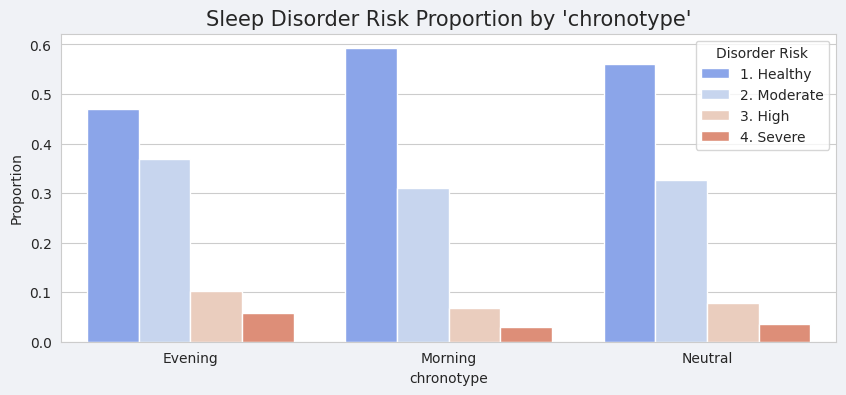

In [21]:
col = 'chronotype'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'work_hours_that_day'
- Work increases the risk of severe sleep disorder

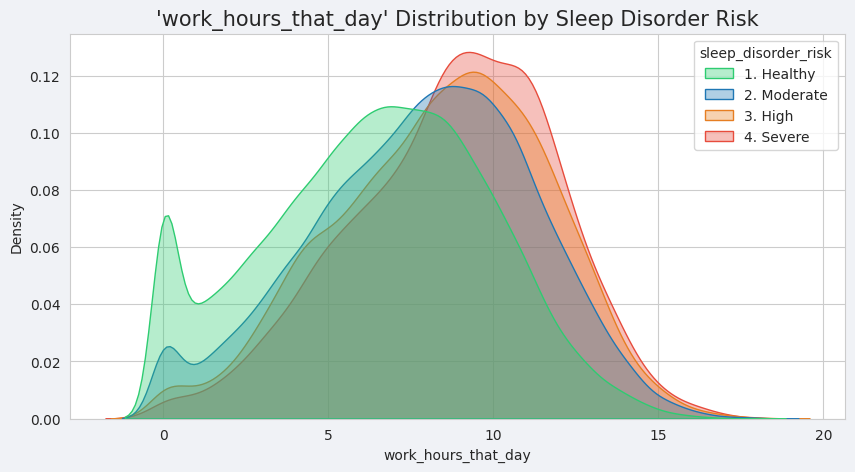

In [22]:
col = 'work_hours_that_day'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** 'stress_score'
- Stress increases the risk of severe sleep disorder

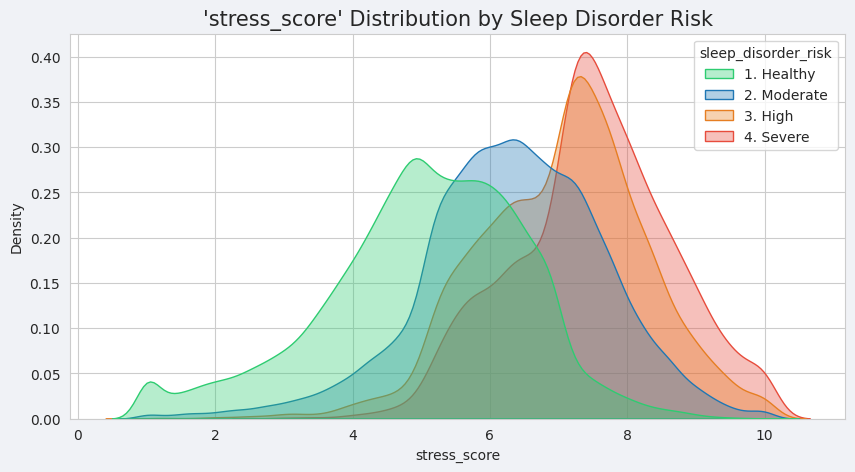

In [23]:
col = 'stress_score'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** 'nap_duration_mins'
- Napping increases the risk of severe sleep disorder

In [24]:
def reduce_nap(x):
    if x==0 : return "No nap"
    elif x<=15 : return "15 minutes"
    elif x<=30 : return "30 minutes"
    elif x<=45 : return "45 minutes"
    elif x<=60 : return "60 minutes"
    else : return "More than 1 hour"

df['nap_time'] = df['nap_duration_mins'].apply(reduce_nap)
pd.crosstab(df['nap_time'], df['sleep_disorder_risk'], normalize='index')

sleep_disorder_risk,1. Healthy,2. Moderate,3. High,4. Severe
nap_time,,,,
15 minutes,0.560448,0.322435,0.080355,0.036763
30 minutes,0.551731,0.327013,0.081486,0.039771
45 minutes,0.533295,0.339481,0.084952,0.042272
60 minutes,0.519956,0.340289,0.092078,0.047677
More than 1 hour,0.504194,0.352749,0.096925,0.046132
No nap,0.545094,0.334534,0.080834,0.039538


### **<u>Feature :</u>** 'screen_time_before_bed_mins'
- Low screen time before bed reduces the risk of severe sleep disorder

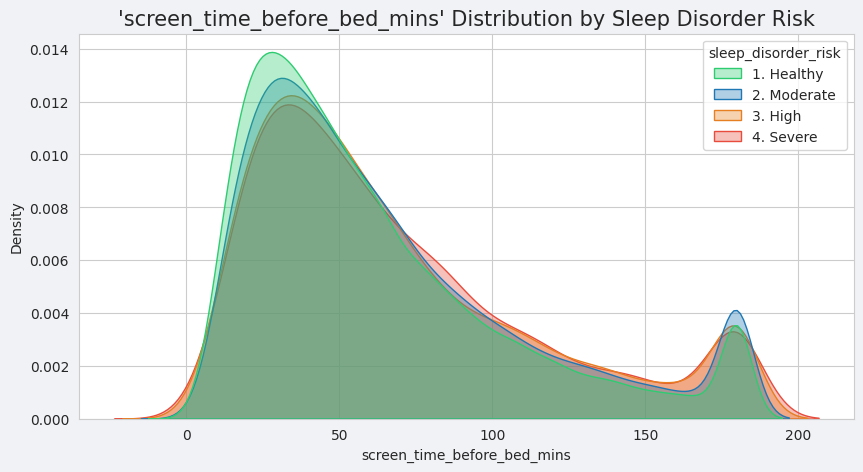

In [25]:
col = 'screen_time_before_bed_mins'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

In [26]:
def reduce_screen_time(x):
    if x<=30 : return "Less than 30 minutes"
    elif x<=60 : return "30-60 minutes"
    elif x<=120 : return "1-2 hours"
    elif x<=180 : return "2-3 hours"
    else : return "More than 3 hours"

df['time_screen_before_sleep'] = df['screen_time_before_bed_mins'].apply(reduce_screen_time)
pd.crosstab(df['time_screen_before_sleep'], df['sleep_disorder_risk'], normalize='index')

sleep_disorder_risk,1. Healthy,2. Moderate,3. High,4. Severe
time_screen_before_sleep,,,,
1-2 hours,0.526637,0.344815,0.085111,0.043437
2-3 hours,0.483252,0.366100,0.101133,0.049515
30-60 minutes,0.545800,0.332154,0.082464,0.039581
Less than 30 minutes,0.581016,0.311832,0.072474,0.034679


### **<u>Feature :</u>** 'alcohol_units_before_bed'
- alcool raises the risk of sever sleep disorder

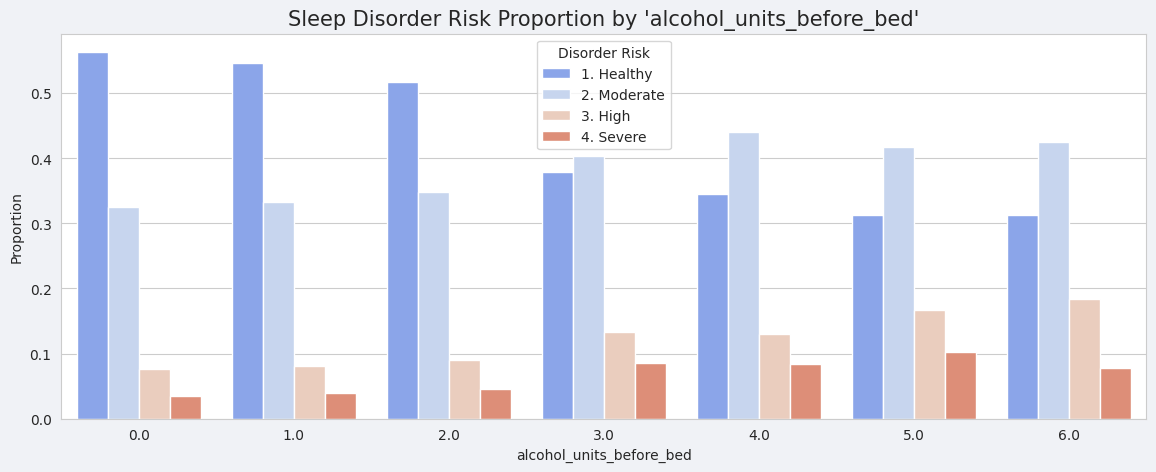

In [27]:
col = 'alcohol_units_before_bed'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(14, 5))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'nb_cafe_before_bed'
- caffeine raises the risk of sever sleep disorder

In [28]:
def reduce_coffee(x):
    if x<=40 : return 0
    elif x<=100 : return 1
    elif x<=200 : return 2
    else : return 3

df['nb_cafe_before_bed'] = df['caffeine_mg_before_bed'].apply(reduce_coffee)

pd.crosstab(df['nb_cafe_before_bed'], df['sleep_disorder_risk'], normalize='index')

sleep_disorder_risk,1. Healthy,2. Moderate,3. High,4. Severe
nb_cafe_before_bed,,,,
0,0.558996,0.326798,0.078236,0.035970
1,0.524343,0.343116,0.087297,0.045244
2,0.492669,0.358696,0.097700,0.050935
3,0.282807,0.445598,0.151578,0.120017


### **<u>Feature :</u>** 'wake_episodes_per_night'
- Waking up often during the night raises the risk of sever sleep disorder

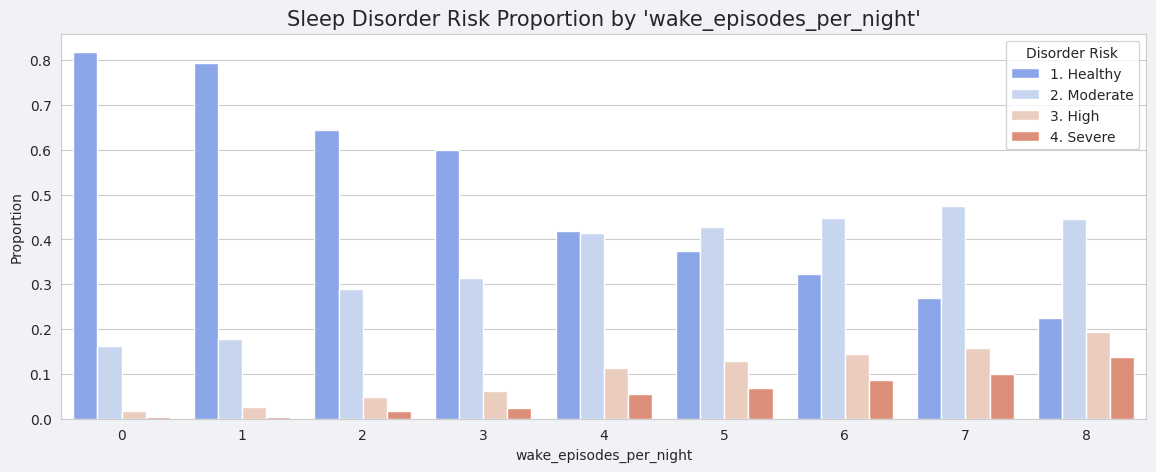

In [29]:
col = 'wake_episodes_per_night'

# Compute proportions
prop_df = df.groupby([col])['sleep_disorder_risk'].value_counts(normalize=True).sort_index().reset_index()

# Plot
plt.figure(figsize=(14, 5))
sns.barplot(
    data=prop_df,
    x=col,
    y='proportion',
    hue='sleep_disorder_risk',
    palette='coolwarm'
)

plt.title(f"Sleep Disorder Risk Proportion by '{col}'", fontsize=15)
plt.ylabel('Proportion')
plt.legend(title='Disorder Risk')
plt.show()

### **<u>Feature :</u>** 'sleep_latency_mins'
- Low sleep latency reduces the risk of sever sleep disorder

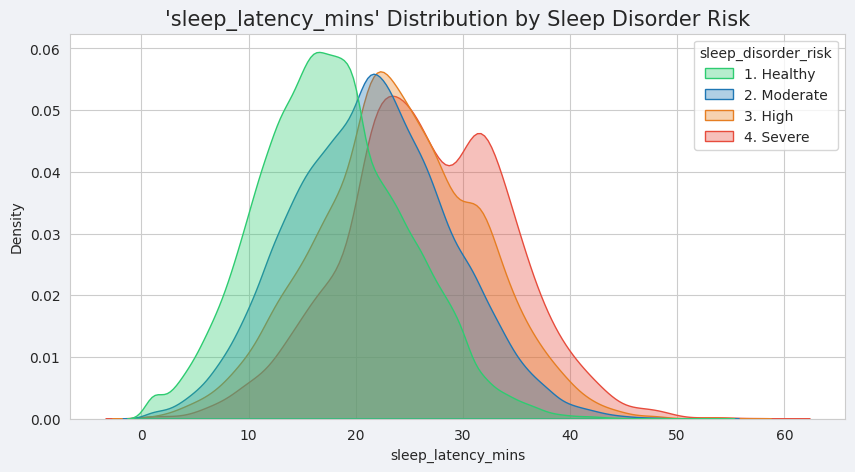

In [30]:
col = 'sleep_latency_mins'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** 'sleep_duration_hrs'
- Sleeping more reduces the risk of sever sleep disorder

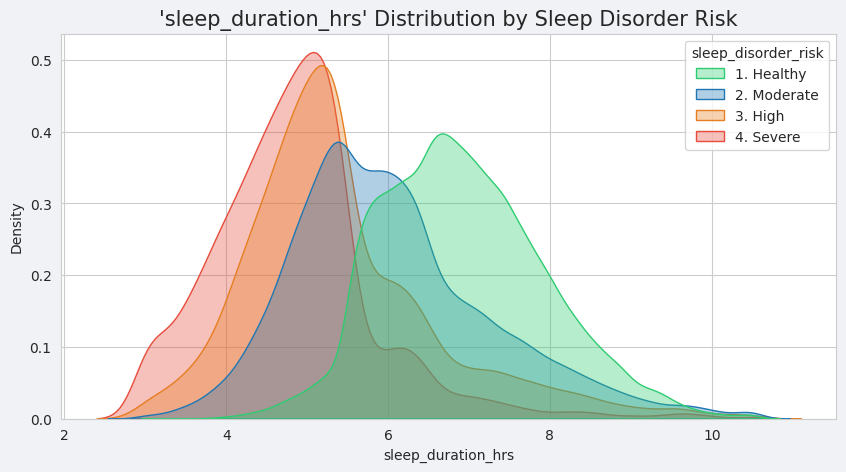

In [31]:
col = 'sleep_duration_hrs'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** age

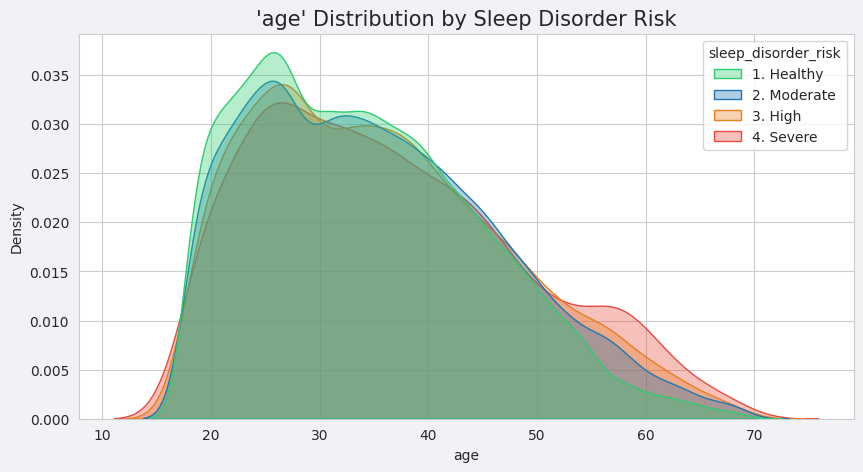

In [32]:
col = 'age'

plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** exercise_day
- People without exercice that day get higher risque of sever sleep disorder

In [33]:
pd.crosstab(df['exercise_day'], df['sleep_disorder_risk'], normalize='index')

sleep_disorder_risk,1. Healthy,2. Moderate,3. High,4. Severe
exercise_day,,,,
0,0.540024,0.333303,0.084072,0.042600
1,0.543431,0.336602,0.081671,0.038295


### **<u>Feature :</u>** bmi
- People with high BMI get higher risk of sever sleep disorder

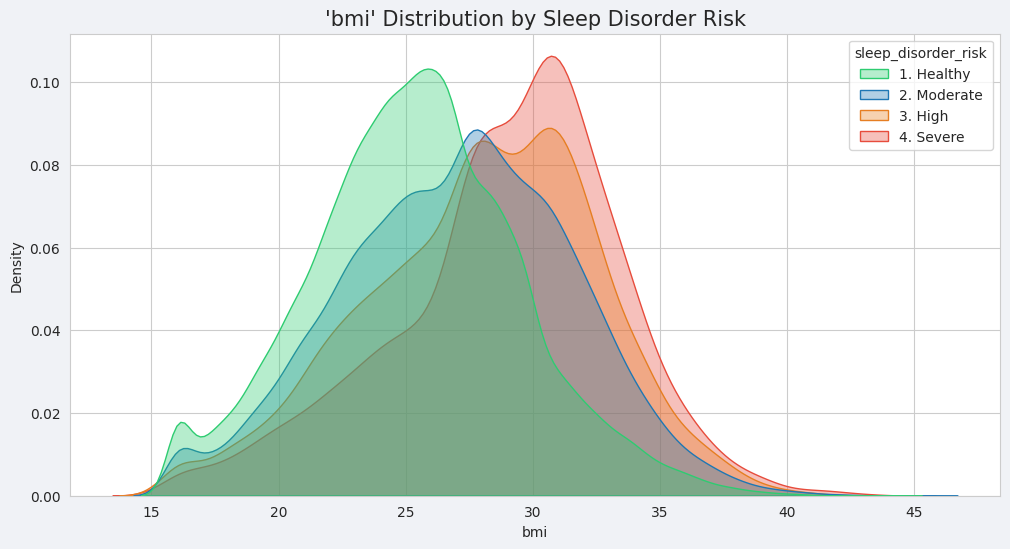

In [34]:
col = 'bmi'

plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=df,
    x=col,
    hue='sleep_disorder_risk',
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette = palette,
    hue_order=order,
)

plt.title(f"'{col}' Distribution by Sleep Disorder Risk", fontsize=15)
plt.xlabel(col)
plt.ylabel('Density')
plt.show()

### **<u>Feature :</u>** 'country'
- French People get higher risk of sever sleep disorder

In [35]:
pd.crosstab(df['country'], df['sleep_disorder_risk'], normalize='index').sort_values(by = '4. Severe', ascending=False)

sleep_disorder_risk,1. Healthy,2. Moderate,3. High,4. Severe
country,,,,
France,0.539743,0.338017,0.079085,0.043155
USA,0.542943,0.331621,0.083192,0.042244
Mexico,0.537037,0.346451,0.074331,0.042181
Japan,0.544072,0.334899,0.078996,0.042032
Canada,0.553954,0.322523,0.081682,0.041842
UK,0.529163,0.342971,0.086117,0.041750
South Korea,0.543440,0.333165,0.082851,0.040544
Italy,0.547038,0.328522,0.084370,0.040070
India,0.538677,0.338397,0.083296,0.039630



# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        🛠️ Feature Engineering </div>


In [36]:
feats = ['sleep_duration_hrs',
         #'cognitive_performance_score',
         'bmi',
         'sleep_latency_mins',
         'stress_score',
         'country',
         'occupation',
         'wake_episodes_per_night',
         'age',
         'work_hours_that_day',
         'Depression',
         'alcohol_units_before_bed',
         'Anxiety',
         'nap_time',
         'nb_cafe_before_bed',
         #'shift_work',
         'time_screen_before_sleep',
         #'exercise_day',
         #'chronotype',
         #'gender',
         #'felt_rested',
         #'sleep_aid_used',
         #'day_type',
        ]

# Show
print(df[feats].shape)
df[feats].head(1)

(100000, 15)


,sleep_duration_hrs,bmi,sleep_latency_mins,stress_score,country,occupation,wake_episodes_per_night,age,work_hours_that_day,Depression,alcohol_units_before_bed,Anxiety,nap_time,nb_cafe_before_bed,time_screen_before_sleep
0,6.19,25.7,16,4.4,Japan,Driver,3,29,10.7,0,0.0,0,No nap,0,30-60 minutes


In [37]:
df[feats].dtypes

sleep_duration_hrs          float64
bmi                         float64
sleep_latency_mins            int64
stress_score                float64
country                      object
occupation                   object
wake_episodes_per_night       int64
age                           int64
work_hours_that_day         float64
Depression                    int64
alcohol_units_before_bed    float64
Anxiety                       int64
nap_time                     object
nb_cafe_before_bed            int64
time_screen_before_sleep     object
dtype: object

In [38]:
# Encode Categorical Variables
categorical_cols = ['day_type', 'chronotype', 'nap_time', 'time_screen_before_sleep', 'country', 'gender', 'occupation']
df[categorical_cols] = df[categorical_cols].astype('category')


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        🚀 Model Training: LightGBM </div>


In [39]:
# KFOLD
n_splits = 10
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=48)

for fold, (train_idx, test_idx) in enumerate(kfold.split(df[feats], df['y'])):
    df.loc[test_idx, 'fold'] = fold
    print(f"Fold {fold} : {len(df.loc[test_idx])} rows.")

Fold 0 : 10000 rows.
Fold 1 : 10000 rows.
Fold 2 : 10000 rows.
Fold 3 : 10000 rows.
Fold 4 : 10000 rows.
Fold 5 : 10000 rows.
Fold 6 : 10000 rows.
Fold 7 : 10000 rows.
Fold 8 : 10000 rows.
Fold 9 : 10000 rows.


In [40]:
fit_params = {"eval_metric" : "mae",
              "eval_names": ['train', 'test'],
              "categorical_feature": 'auto'
             }

model_params = {'objective': 'regression', 'metric': 'mae', 'verbosity': -1, 'boosting_type': 'gbdt', 'random_state': 20, 'n_estimators': 10000, 'n_jobs': 3,
                'learning_rate': 0.05,
                'reg_alpha': 0.9,
                'reg_lambda': 9,
                'max_depth': 10,
                'colsample_bytree': 0.75,
                'subsample': 0.75,
                'min_child_samples': 50}

In [41]:
%%time

# Feature Importance
Feature_Imp = None

# Initialize OOF
df['oof'] = 0
df['pred'] = 0
iterations = []

# Loop over folds
for fold in range(n_splits):

    # Index
    train_idx, test_idx = (df['fold']!=fold), (df['fold']==fold)

    # Create train & test
    xtr, ytr = df.loc[train_idx, feats], df.loc[train_idx, 'y']
    xte, yte = df.loc[test_idx, feats], df.loc[test_idx, 'y']

    # Create model
    fit_params["eval_set"] = [(xte, yte)]
    model = lgb.LGBMRegressor(**model_params)

    # Fit model
    model.fit(xtr, ytr,
              **fit_params,
              callbacks = [lgb.log_evaluation(0),
                           lgb.early_stopping(30, verbose=0),
                          ]
             )

    iterations.append(model.n_iter_)
    
    # Save model
    joblib.dump(model, os.path.join("/kaggle/working/", f"lgbm_fold{fold}.joblib"))

    # Get score of the fold (cross-validation)
    preds = model.predict(xte)
    df.loc[test_idx, 'oof'] = preds
    df.loc[test_idx, 'pred'] = round(df.loc[test_idx, 'oof'].clip(1, 4))
    mae = mean_absolute_error(yte, preds)
    accuracy = accuracy_score(df.loc[test_idx, 'y'], df.loc[test_idx, 'pred'])
    f1_macro = f1_score(df.loc[test_idx, 'y'], df.loc[test_idx, 'pred'], average='macro')

    print(f"Fold {str(fold).ljust(2)} : mae = {str(round(mae, 3)).ljust(6)} / F1 Macro = {f1_macro:.3f} / Accuracy = {accuracy:.3f}.")

    # Update feature importance
    feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, feats)), columns=['Value','Feature'])
    feature_imp['Value'] = 100* (feature_imp['Value'] / feature_imp['Value'].max()) # Normalisation
    feature_imp = dict(zip(feature_imp['Feature'], feature_imp['Value']))
    if Feature_Imp is None :
        Feature_Imp = feature_imp.copy()
    else :
        for k in Feature_Imp.keys():
            Feature_Imp[k] += feature_imp[k]

# ---------------------------------------------------------------------------------------------------
# Features Importance : create a dataframe
Feature_Imp = pd.DataFrame(Feature_Imp.items(), columns=['Feature', 'Value'])
Feature_Imp['Value'] = 100* (Feature_Imp['Value'] / Feature_Imp['Value'].max()) # Normalisation
Feature_Imp = Feature_Imp.sort_values(by='Value', ascending=False).reset_index(drop=True)

# ---------------------------------------------------------------------------------------------------
# Print score
mae = mean_absolute_error(df['y'], df['oof'])
accuracy = accuracy_score(df['y'], df['pred'])
f1_macro = f1_score(df['y'], df['pred'], average='macro')

print(f"Final score : mae = {str(round(mae, 4)).ljust(5)} / F1 Macro = {f1_macro:.3f} / Accuracy = {accuracy:.3f}.")
print('-'*50 + '\n\n')

<timed exec>:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.63507446 2.3051008  1.6586336  ... 1.78427    2.38239763 0.96238462]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


Fold 0  : mae = 0.189  / F1 Macro = 0.842 / Accuracy = 0.930.
Fold 1  : mae = 0.191  / F1 Macro = 0.853 / Accuracy = 0.932.
Fold 2  : mae = 0.192  / F1 Macro = 0.852 / Accuracy = 0.929.
Fold 3  : mae = 0.189  / F1 Macro = 0.855 / Accuracy = 0.932.
Fold 4  : mae = 0.192  / F1 Macro = 0.861 / Accuracy = 0.932.
Fold 5  : mae = 0.19   / F1 Macro = 0.856 / Accuracy = 0.931.
Fold 6  : mae = 0.187  / F1 Macro = 0.856 / Accuracy = 0.932.
Fold 7  : mae = 0.192  / F1 Macro = 0.853 / Accuracy = 0.931.
Fold 8  : mae = 0.19   / F1 Macro = 0.853 / Accuracy = 0.932.
Fold 9  : mae = 0.19   / F1 Macro = 0.847 / Accuracy = 0.929.
Final score : mae = 0.1901 / F1 Macro = 0.853 / Accuracy = 0.931.
--------------------------------------------------


CPU times: user 1min 54s, sys: 1.62 s, total: 1min 56s
Wall time: 39.8 s



# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        🔍 Feature Importance Analysis </div>


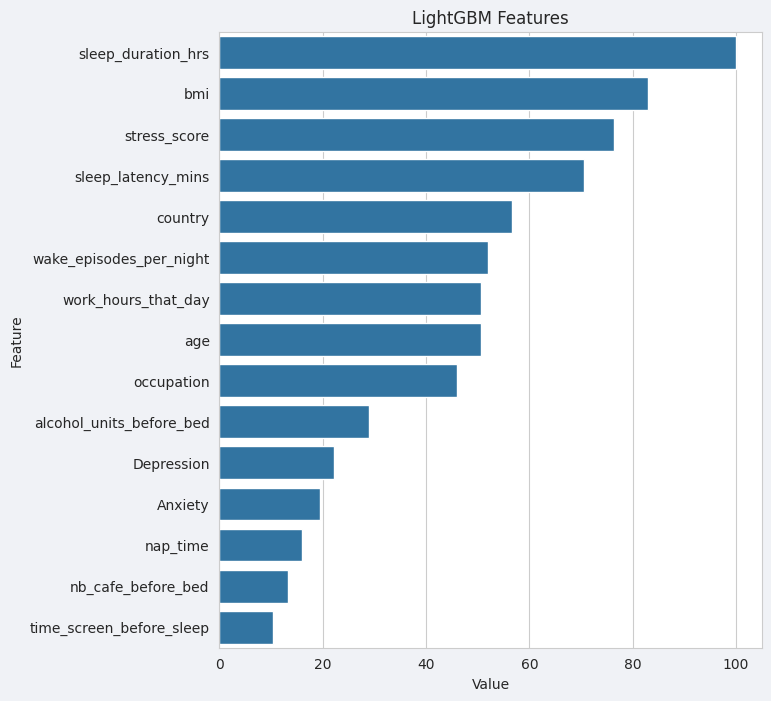

In [42]:
# Feature Importance
plt.figure(figsize=(7, 8))
sns.barplot(x="Value", y="Feature", data=Feature_Imp.head(60))
plt.title('LightGBM Features')
plt.show()

In [43]:
Feature_Imp.Feature.to_list()

['sleep_duration_hrs',
 'bmi',
 'stress_score',
 'sleep_latency_mins',
 'country',
 'wake_episodes_per_night',
 'work_hours_that_day',
 'age',
 'occupation',
 'alcohol_units_before_bed',
 'Depression',
 'Anxiety',
 'nap_time',
 'nb_cafe_before_bed',
 'time_screen_before_sleep']


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        📉 Confusion Matrix Visualization </div>


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted Label', ylabel='True Label'>)

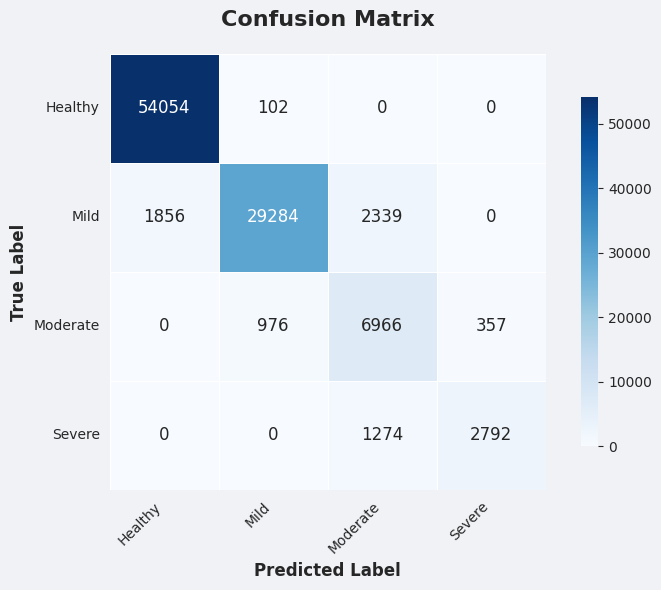

In [44]:
# Matrice de confusion
plot_confusion_matrix(df['y'], df['pred'], class_names=['Healthy', 'Mild', 'Moderate', 'Severe'])


# <div style="background-image: linear-gradient(90deg, #203a43 50%, #2c5364 100%);             color: white;             padding: 12px 25px;             border-radius: 30px;             font-size: 1.4rem;             display: inline-block;             font-weight: bold;             letter-spacing: 1px;             box-shadow: 2px 4px 10px rgba(0,0,0,0.3);             font-family: 'Segoe UI', Tahoma, sans-serif;">        📉 Train one single model </div>


In [45]:
median_iter = np.median(iterations)

print(iterations)
print(median_iter)

[687, 762, 880, 600, 700, 666, 867, 530, 511, 873]
693.5


In [46]:
%%time

# Create params
full_model_params = {k:v for k, v in model_params.items()}
full_model_params['n_estimators'] = int(median_iter)

# Create model
fit_params["eval_set"] = [(df[feats], df['y'])]
full_model = lgb.LGBMRegressor(**full_model_params)

# Fit model
full_model.fit(df[feats],
               df['y'],
               **fit_params,
              )

# Save model
joblib.dump(full_model, os.path.join("/kaggle/working/", f"lgbm_full.joblib"))

CPU times: user 15.4 s, sys: 155 ms, total: 15.5 s
Wall time: 5.26 s


['/kaggle/working/lgbm_full.joblib']

___
___
# **Model Explicability**
Shap Values

In [47]:
%%time

# Select training data
X = df[feats]

# Compute shap values
explainer = shap.TreeExplainer(full_model)
shap_values = explainer.shap_values(X)

# Save
joblib.dump(shap_values, "shap_values.joblib")

# Create shap df
shap_df = pd.DataFrame(shap_values, columns=feats)

# Aperçu
print(shap_df.shape)
shap_df.head()

(100000, 15)
CPU times: user 14min 51s, sys: 558 ms, total: 14min 51s
Wall time: 3min 45s


,sleep_duration_hrs,bmi,sleep_latency_mins,stress_score,country,occupation,wake_episodes_per_night,age,work_hours_that_day,Depression,alcohol_units_before_bed,Anxiety,nap_time,nb_cafe_before_bed,time_screen_before_sleep
0,-0.103951,-0.093988,-0.081561,-0.132844,0.003160,0.005574,-0.062361,-0.008177,-0.005414,-0.097779,-0.017538,-0.073617,0.000854,-0.005977,-0.000298
1,-0.236066,-0.087547,-0.083261,-0.133860,0.001415,0.002004,0.064961,-0.006291,0.006459,-0.095606,-0.016084,-0.071181,-0.000787,-0.004570,0.000562
2,0.851545,-0.176183,0.115966,0.318964,-0.004190,0.019422,0.228675,-0.009825,0.002868,0.656351,0.014094,0.342339,-0.008068,-0.007644,0.004852
3,-0.269115,0.023947,-0.098050,-0.171657,-0.001097,-0.006003,0.080080,-0.008971,-0.000166,-0.111571,-0.018828,-0.092291,-0.001285,-0.005416,-0.000189
4,0.630615,-0.201507,0.094898,0.272056,-0.004732,-0.013934,0.177088,-0.012511,-0.004121,-0.175519,-0.036142,-0.152273,-0.000296,-0.007151,-0.000956


# **Importance des variables selon les Shap Values**

### Factors increasing the risk of sleep disorders
- Low sleep suration
- Depression, Stress & Anxiety
- High BMI
  Depression & Anxiety
- Alcool & Coffee

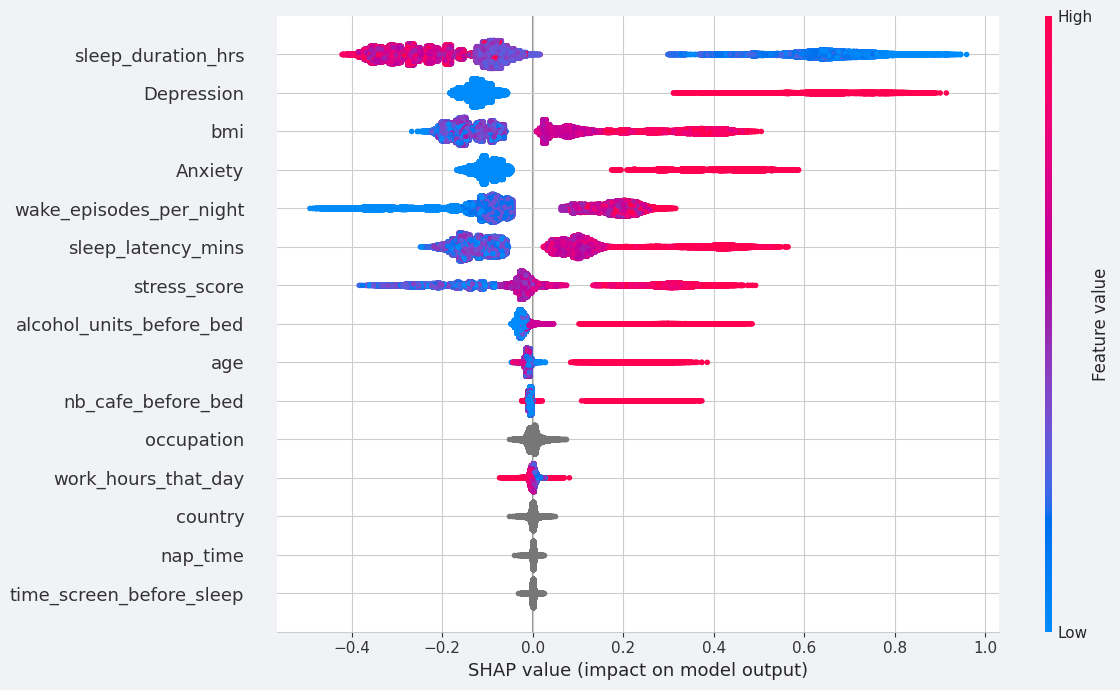

In [48]:
shap.summary_plot(
    shap_df.values,
    X,
    feature_names=feats,
    plot_size=(12, 7)
)

## **Individual Contributions to explain a single prediction**

In [49]:
def plot_shap_value_for_one_row(base_value, shap_row, row, feats):
    shap.force_plot(
        base_value=base_value,
        shap_values=shap_row,
        features=row[feats],
        feature_names=feats,
        matplotlib=True,
        text_rotation=15,
        figsize=(12, 3)
    )
    plt.show()

def plot_shap_waterfall_for_one_row(base_value, shap_row, row, feats):
    exp = shap.Explanation(
        values=shap_row,
        base_values=base_value,
        data=row[feats],
        feature_names=feats
    )

    plt.figure(figsize=(10, 3))
    shap.plots.waterfall(exp, max_display=10)
    plt.show()

### **Row with low score (healthy sleep)**

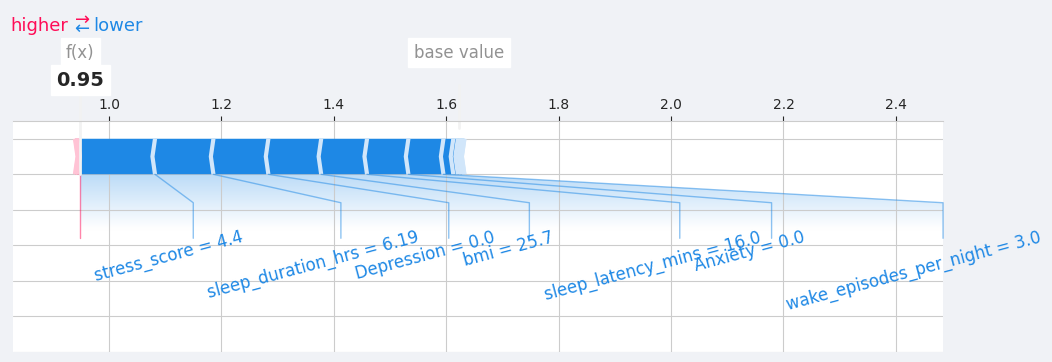

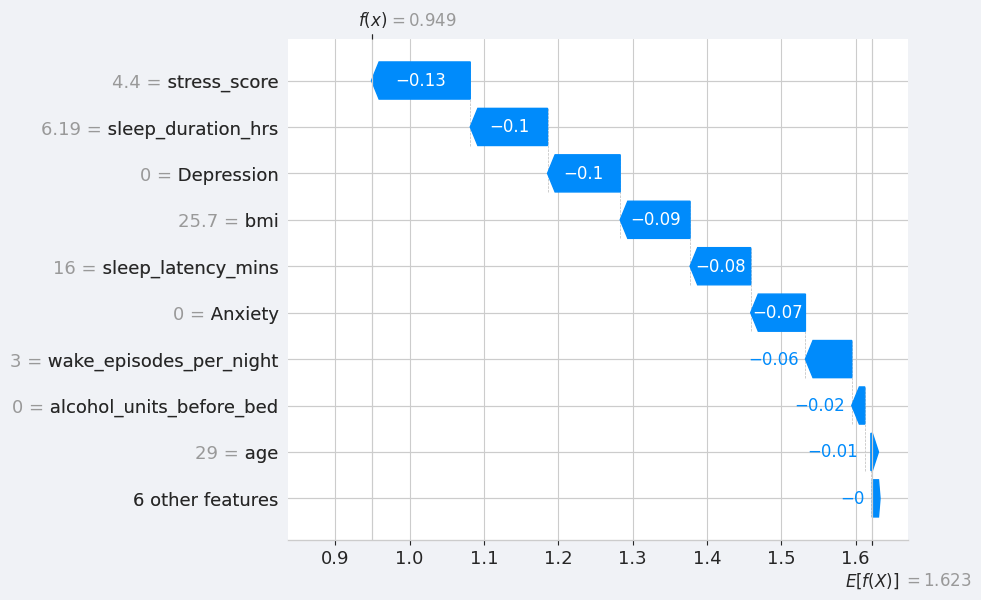

CPU times: user 1.03 s, sys: 38.8 ms, total: 1.07 s
Wall time: 1.09 s


In [50]:
%%time

# Row id
sample_idx = 0

plot_shap_value_for_one_row(
    base_value=explainer.expected_value,
    shap_row=shap_values[sample_idx],
    row=df.iloc[sample_idx],
    feats=feats
)

plot_shap_waterfall_for_one_row(
    base_value=explainer.expected_value,
    shap_row=shap_df.iloc[sample_idx].values,
    row=df.iloc[sample_idx],
    feats=feats
)

### **Row with high score (sleep disorder)**

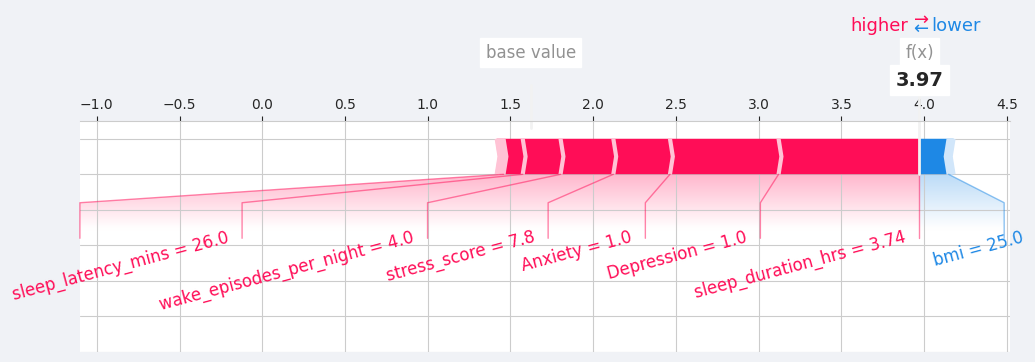

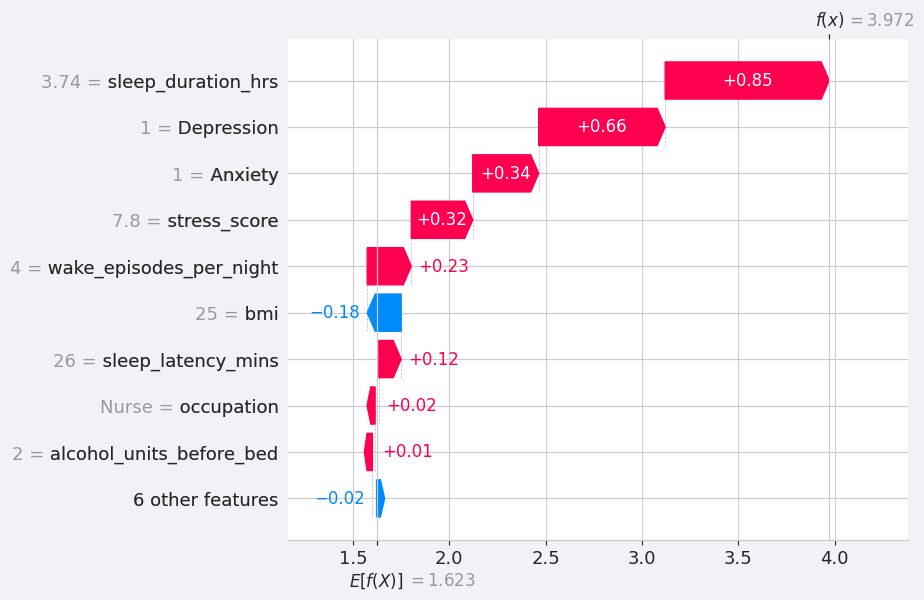

CPU times: user 744 ms, sys: 26 ms, total: 770 ms
Wall time: 769 ms


In [51]:
%%time

# Row id
sample_idx = 2

plot_shap_value_for_one_row(
    base_value=explainer.expected_value,
    shap_row=shap_values[sample_idx],
    row=df.iloc[sample_idx],
    feats=feats
)

plot_shap_waterfall_for_one_row(
    base_value=explainer.expected_value,
    shap_row=shap_df.iloc[sample_idx].values,
    row=df.iloc[sample_idx],
    feats=feats
)